# 看懂大语言模型的配置

> 上一节用硬编码参数搭了一台 Mini-GPT：vocab_size=30、d_model=64、num_heads=4、num_layers=2。真实模型不会把结构参数埋在代码里，而是集中写在一个叫 config.json 的文件中。
>
> 这一节打开 HuggingFace 上 SmolLM2-135M 的 config.json——一台 1.35 亿参数的真模型——逐字段解释每个参数的含义，它和前面学到的概念是什么关系，教学代码和工程实践之间有哪些差异。

HuggingFace 上每个模型仓库的根目录下都有一个 config.json。它是模型的结构参数表：Tokenizer 管文本怎么切，config.json 管模型怎么搭——多少层、多宽、多少个注意力头、用什么激活函数。掌握 config.json，就掌握了读懂任何开源模型的第一步。

选 SmolLM2-135M 作为示例有几个原因。它是目前公开可访问的最小的现代 LLM 之一（仅 1.35 亿参数），但配置完整——GQA、RoPE、RMSNorm、SiLU、weight tying 一样不少。它的架构类型是 LlamaForCausalLM，这是当前开源社区使用最广泛的模型家族，LLaMA、Mistral、Qwen 等都属于这个家族或其变体。弄懂这一份 config.json，再看其他模型就轻车熟路。

In [1]:
import torch
import json

_ = torch.manual_seed(42)

## 1. 看一眼完整的 config.json

访问 HuggingFace 上任意模型仓库，在「Files and versions」标签页里找到 config.json，就能看到这个模型的全部结构参数。也可以在模型页面 URL 后面直接拼 `/blob/main/config.json` 跳转过去。

下面用 Python 字典把 [SmolLM2-135M 的 config.json](https://huggingface.co/HuggingFaceTB/SmolLM2-135M/blob/main/config.json) 完整写出来：

In [2]:
config = {
    "architectures": ["LlamaForCausalLM"],
    "attention_bias": False,
    "attention_dropout": 0.0,
    "bos_token_id": 0,
    "eos_token_id": 0,
    "hidden_act": "silu",
    "hidden_size": 576,
    "initializer_range": 0.041666666666666664,
    "intermediate_size": 1536,
    "is_llama_config": True,
    "max_position_embeddings": 8192,
    "model_type": "llama",
    "num_attention_heads": 9,
    "num_hidden_layers": 30,
    "num_key_value_heads": 3,
    "pretraining_tp": 1,
    "rms_norm_eps": 1e-05,
    "rope_interleaved": False,
    "rope_scaling": None,
    "rope_theta": 100000,
    "tie_word_embeddings": True,
    "torch_dtype": "bfloat16",
    "transformers_version": "4.40.1",
    "use_cache": True,
    "vocab_size": 49152,
}

print("SmolLM2-135M 完整 config.json：")
print(json.dumps(config, indent=2, ensure_ascii=False))

print(f"\n关键观察：就这 {len(config)} 个字段，定义了整台模型的结构。")
print(f"  词表多大？vocab_size = {config['vocab_size']}")
print(f"  模型多宽？hidden_size = {config['hidden_size']}")
print(f"  模型多深？num_hidden_layers = {config['num_hidden_layers']}")
print(f"  几个注意力头？num_attention_heads = {config['num_attention_heads']}")

SmolLM2-135M 完整 config.json：
{
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "eos_token_id": 0,
  "hidden_act": "silu",
  "hidden_size": 576,
  "initializer_range": 0.041666666666666664,
  "intermediate_size": 1536,
  "is_llama_config": true,
  "max_position_embeddings": 8192,
  "model_type": "llama",
  "num_attention_heads": 9,
  "num_hidden_layers": 30,
  "num_key_value_heads": 3,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_interleaved": false,
  "rope_scaling": null,
  "rope_theta": 100000,
  "tie_word_embeddings": true,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.40.1",
  "use_cache": true,
  "vocab_size": 49152
}

关键观察：就这 25 个字段，定义了整台模型的结构。
  词表多大？vocab_size = 49152
  模型多宽？hidden_size = 576
  模型多深？num_hidden_layers = 30
  几个注意力头？num_attention_heads = 9


## 2. 逐字段解读

26 个字段按功能分成七组。每一组先解释字段的含义，再把它和前面学过的概念对上。

### 2.1 身份信息：这是什么模型

`architectures` 告诉 transformers 库用哪个类来加载模型。`["LlamaForCausalLM"]` 表示这是一个 Decoder-Only 的因果语言模型——和 05 节实现的因果自注意力属于同一类型。它只做一件事：根据前面的 token 预测下一个 token。

`model_type` 决定模型内部的具体实现细节。`"llama"` 意味着这个模型使用 Llama 风格的 FFN（带 gate 的三线性层结构）和 RMSNorm，而不是 05 节里最基础的 ReLU + LayerNorm 实现。

In [3]:
print("=== 身份信息 ===")
print(f"architectures: {config['architectures']}")
print(f"  → Decoder-Only 因果语言模型，和 05 节的 Causal Mask 同一思路")
print(f"model_type: {config['model_type']}")
print(f"  → Llama 架构：FFN 带 gate、用 RMSNorm")

=== 身份信息 ===
architectures: ['LlamaForCausalLM']
  → Decoder-Only 因果语言模型，和 05 节的 Causal Mask 同一思路
model_type: llama
  → Llama 架构：FFN 带 gate、用 RMSNorm


### 2.2 词表与 Embedding

`vocab_size` 是词表大小，决定了 Embedding 矩阵有多少行。49,152 这个数字不是随便选的——它是 128 的倍数，方便 GPU 上的内存对齐和并行计算。

`tie_word_embeddings: true` 表示输入 Embedding 和输出 lm_head 共享同一张权重矩阵。这和 03 节学过的权重共享完全一致。共享后，这 28.3M 参数不需要存两份。

Embedding 参数量 = vocab_size × hidden_size = 49,152 × 576 ≈ 28.3M，占模型总参数（~135M）的约 21%。

In [4]:
vocab_size = config['vocab_size']
hidden_size = config['hidden_size']
emb_params = vocab_size * hidden_size

print("=== 词表与 Embedding ===")
print(f"vocab_size = {vocab_size:,}")
print(f"  → 128 的倍数 ({vocab_size} = 128 × {vocab_size // 128})，方便 GPU 对齐")
print(f"tie_word_embeddings = {config['tie_word_embeddings']}")
print(f"  → 输入 Embedding 和输出 lm_head 共享权重，和 03 节一致")
print(f"\nEmbedding 参数量: {vocab_size:,} × {hidden_size} = {emb_params:,} ≈ {emb_params / 1e6:.1f}M")
print(f"占模型总参数 (~135M) 的约 {emb_params / 135e6 * 100:.0f}%")

=== 词表与 Embedding ===
vocab_size = 49,152
  → 128 的倍数 (49152 = 128 × 384)，方便 GPU 对齐
tie_word_embeddings = True
  → 输入 Embedding 和输出 lm_head 共享权重，和 03 节一致

Embedding 参数量: 49,152 × 576 = 28,311,552 ≈ 28.3M
占模型总参数 (~135M) 的约 21%


### 2.3 模型尺寸：多宽、多深、多胖

`hidden_size`（也叫 d_model）是贯穿整个模型的向量维度。从 Embedding 查出来的向量、Attention 的 Q/K/V、FFN 的输入输出，全都走这个宽度。576 这个值比 GPT-2 Small 的 768 还要窄一些。

`num_hidden_layers` 是 Transformer Block 堆叠的层数。30 层配合仅 576 的宽度，是一个「又深又窄」的设计——每层不宽，但层数很多。这和 GPT-2 那种「宽而浅」（12 层 × 768 维）的策略不同，各有取舍。

`intermediate_size` 是 FFN 中间层的维度。Llama 架构使用 8/3 的扩展比例：576 × 8/3 ≈ 1,536。而 05 节我们用的是 4 倍扩展。不同的比例影响 FFN 的参数量和表达能力。

In [5]:
n_layers = config['num_hidden_layers']
intermediate = config['intermediate_size']

print("=== 模型尺寸 ===")
print(f"hidden_size (d_model) = {hidden_size}")
print(f"  → 贯穿 Embedding、Attention、FFN 的通道宽度")
print(f"num_hidden_layers = {n_layers}")
print(f"  → {n_layers} 层 Transformer Block 堆叠")
print(f"intermediate_size = {intermediate:,}")
print(f"  → Llama 用 8/3 比例: {hidden_size} × 8/3 ≈ {hidden_size * 8 / 3:.0f}")
print(f"  → 我们 05 节用的是 4 倍: {hidden_size} × 4 = {hidden_size * 4}")
print(f"\n架构特点：{n_layers} 层 × {hidden_size} 维 → 又深又窄")

=== 模型尺寸 ===
hidden_size (d_model) = 576
  → 贯穿 Embedding、Attention、FFN 的通道宽度
num_hidden_layers = 30
  → 30 层 Transformer Block 堆叠
intermediate_size = 1,536
  → Llama 用 8/3 比例: 576 × 8/3 ≈ 1536
  → 我们 05 节用的是 4 倍: 576 × 4 = 2304

架构特点：30 层 × 576 维 → 又深又窄


### 2.4 注意力配置：GQA 登场

`num_attention_heads=9` 表示有 9 个 Query 头。每个头的维度是 hidden_size / num_heads = 576 / 9 = 64 维。

`num_key_value_heads=3` 是关键信息——KV 头只有 3 个，不是 9 个。这意味着每 3 个 Q 头共享 1 组 KV 头。这就是 GQA（Grouped Query Attention）。

05 节我们实现的 MHA 是 Q、K、V 头数相同（都是 4）。GQA 减少了 KV 头的数量，可以显著节省推理时的显存——KV cache 的大小和 KV 头数成正比。从 MHA 到 GQA，是工业界在实践中做出的重要改进。

`attention_bias=False` 表示 Q、K、V 的投影矩阵不带 bias 项。这也是 Llama 系列的一个小优化——省掉 bias 可以减少一点参数，对效果影响很小。

In [6]:
n_q_heads = config['num_attention_heads']
n_kv_heads = config['num_key_value_heads']
head_dim = hidden_size // n_q_heads
groups_per_kv = n_q_heads // n_kv_heads

print("=== 注意力配置 ===")
print(f"num_attention_heads (Q 头数) = {n_q_heads}")
print(f"  每个头维度: {hidden_size} / {n_q_heads} = {head_dim}")
print(f"num_key_value_heads (KV 头数) = {n_kv_heads}")
print(f"  → GQA: {groups_per_kv} 个 Q 头共享 1 组 KV 头")
print(f"  → 05 节 MHA: Q=K=V={n_q_heads} 头")
print(f"  → GQA: Q={n_q_heads} 头, K=V={n_kv_heads} 头")
print(f"\nattention_bias = {config['attention_bias']}")
print(f"  → Q/K/V 投影不带 bias，节省参数")
print(f"attention_dropout = {config['attention_dropout']}")
print(f"  → 小模型不加 dropout")

=== 注意力配置 ===
num_attention_heads (Q 头数) = 9
  每个头维度: 576 / 9 = 64
num_key_value_heads (KV 头数) = 3
  → GQA: 3 个 Q 头共享 1 组 KV 头
  → 05 节 MHA: Q=K=V=9 头
  → GQA: Q=9 头, K=V=3 头

attention_bias = False
  → Q/K/V 投影不带 bias，节省参数
attention_dropout = 0.0
  → 小模型不加 dropout


### 2.5 位置编码：从 Sinusoidal 到 RoPE

`max_position_embeddings=8192` 是这个模型能处理的最长序列长度。超过 8192 个 token 的输入，模型就无法保证效果。

`rope_theta=100000` 是 RoPE（Rotary Position Embedding）的 base frequency。RoPE 和 04 节学的 Sinusoidal 位置编码目标相同——让模型知道每个 token 在序列中的位置——但做法不同。Sinusoidal 是把位置向量直接加到 Embedding 上，RoPE 是把位置信息编码到 Attention 的 QK 点积里：通过旋转 Q 和 K 向量，让它们的内积自然地带上相对位置信息。

`rope_theta` 控制旋转频率。值越大，高频旋转越慢，模型对远距离位置的区分能力越强。100,000 是一个中等偏高的值。

`rope_scaling=null` 表示没有做长度外推。如果需要支持超过 8192 的上下文，可以通过设置这个字段来扩展。

In [7]:
print("=== 位置编码 ===")
print(f"max_position_embeddings = {config['max_position_embeddings']:,}")
print(f"  → 最长上下文窗口: {config['max_position_embeddings']:,} tokens")
print(f"rope_theta = {config['rope_theta']:,}")
print(f"  → RoPE 的 base frequency，控制旋转速度")
print(f"rope_scaling = {config['rope_scaling']}")
print(f"  → 不做长度外推")
print(f"\n04 节: Sinusoidal → 位置向量直接加到 Embedding")
print(f"SmolLM2: RoPE → 位置信息编码在 QK 点积里，自然捕捉相对位置")

=== 位置编码 ===
max_position_embeddings = 8,192
  → 最长上下文窗口: 8,192 tokens
rope_theta = 100,000
  → RoPE 的 base frequency，控制旋转速度
rope_scaling = None
  → 不做长度外推

04 节: Sinusoidal → 位置向量直接加到 Embedding
SmolLM2: RoPE → 位置信息编码在 QK 点积里，自然捕捉相对位置


### 2.6 归一化与激活

`rms_norm_eps=1e-05` 是 RMSNorm 的 epsilon 参数。05 节我们用的是 LayerNorm——它对输入做平移（减均值）和缩放（除标准差）。RMSNorm 只做缩放，省掉了平移这一步，计算更快，效果在 LLM 中反而更好。epsilon 是为了防止除以零加的一个极小常数。

`hidden_act="silu"` 是 FFN 中使用的激活函数。SiLU（Sigmoid Linear Unit，也叫 Swish）的公式是 $x \cdot \sigma(x)$——输入乘以它自身的 sigmoid。和 05 节的 ReLU 相比，SiLU 是光滑曲线，没有 ReLU 在 x=0 处的「折断」，梯度流动更顺畅。现代 LLM 几乎全部使用 SiLU。

/Users/sanbu/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33410 (\N{CJK UNIFIED IDEOGRAPH-8282}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sanbu/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20351 (\N{CJK UNIFIED IDEOGRAPH-4F7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sanbu/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


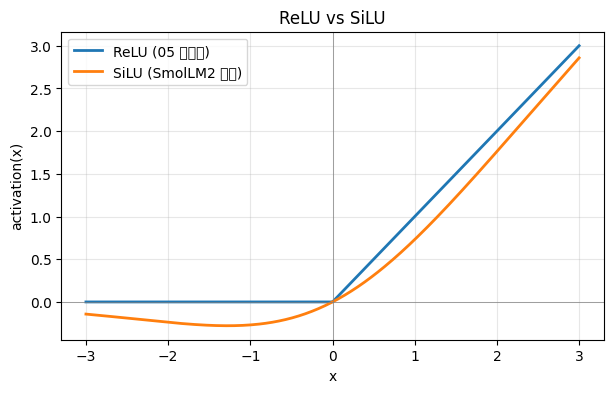

=== 归一化与激活 ===
rms_norm_eps = 1e-05
  → RMSNorm: 只做缩放不做平移，比 LayerNorm 更快
hidden_act = 'silu'
  → SiLU = x·σ(x)，比 ReLU 光滑，梯度流动更顺畅

05 节: LayerNorm + ReLU
SmolLM2: RMSNorm + SiLU


In [8]:
# 可视化 ReLU vs SiLU
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-3, 3, 300)
relu = np.maximum(0, x)
silu = x / (1 + np.exp(-x))  # x * sigmoid(x)

plt.figure(figsize=(7, 4))
plt.plot(x, relu, label="ReLU (05 节使用)", linewidth=2)
plt.plot(x, silu, label="SiLU (SmolLM2 使用)", linewidth=2)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel("x")
plt.ylabel("activation(x)")
plt.title("ReLU vs SiLU")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("=== 归一化与激活 ===")
print(f"rms_norm_eps = {config['rms_norm_eps']}")
print(f"  → RMSNorm: 只做缩放不做平移，比 LayerNorm 更快")
print(f"hidden_act = '{config['hidden_act']}'")
print(f"  → SiLU = x·σ(x)，比 ReLU 光滑，梯度流动更顺畅")
print(f"\n05 节: LayerNorm + ReLU")
print(f"SmolLM2: RMSNorm + SiLU")

### 2.7 其他字段

剩余字段负责初始化、精度、推理等配置。逐一过一遍：

`bos_token_id` / `eos_token_id`：序列开始和结束的特殊 token ID。SmolLM2 中两者都是 0——它没有专门的 BOS token，EOS 复用 ID 0。

`initializer_range`：参数初始化的标准差。0.0416667 = 1/24。Llama 架构用这个特定值初始化权重，配合 RMSNorm 和 SiLU 使用。

`pretraining_tp`：预训练时 Tensor Parallelism 的度数。1 表示单卡训练，没有做模型并行。

`torch_dtype`：模型默认使用的浮点精度。bfloat16 是 Google 提出的 16 位浮点格式，范围和 FP32 一样大（8 位指数），但精度只有 7 位——训练快、显存省，对模型效果影响很小。

`use_cache`：推理时是否缓存每一层的 KV 值。缓存后，生成新 token 时只需要算最新那个位置的 Q，前面位置的 K 和 V 直接从缓存读——推理速度大幅提升。

In [9]:
print("=== 其他字段 ===")
print(f"bos_token_id = {config['bos_token_id']}")
print(f"eos_token_id = {config['eos_token_id']}")
print(f"  → BOS 和 EOS 共用 ID=0")
print(f"initializer_range = {config['initializer_range']}")
print(f"  → 1/24 ≈ {1/24:.6f}，Llama 的特定初始化标准差")
print(f"pretraining_tp = {config['pretraining_tp']}")
print(f"  → 单卡训练，未做模型并行")
print(f"torch_dtype = '{config['torch_dtype']}'")
print(f"  → BF16: 8 位指数 + 7 位尾数，范围和 FP32 一样大")
print(f"use_cache = {config['use_cache']}")
print(f"  → 推理时缓存 KV，新 token 只需算一个位置的 Attention")
print(f"transformers_version = '{config['transformers_version']}'")
print(f"  → 保存模型时使用的 transformers 版本号")

=== 其他字段 ===
bos_token_id = 0
eos_token_id = 0
  → BOS 和 EOS 共用 ID=0
initializer_range = 0.041666666666666664
  → 1/24 ≈ 0.041667，Llama 的特定初始化标准差
pretraining_tp = 1
  → 单卡训练，未做模型并行
torch_dtype = 'bfloat16'
  → BF16: 8 位指数 + 7 位尾数，范围和 FP32 一样大
use_cache = True
  → 推理时缓存 KV，新 token 只需算一个位置的 Attention
transformers_version = '4.40.1'
  → 保存模型时使用的 transformers 版本号


## 3. 对照我们的教学实现

走完 config.json 的每一组字段后，把它和 01-06 节的教学实现放在一起看。下面这张表把差异一次列出来：

In [10]:
print("=== 教学实现 vs SmolLM2-135M 对照 ===")
print()
print(f"{'概念':<20} {'Mini-GPT (教学)':<28} {'SmolLM2-135M (实际)':<28}")
print("-" * 78)

comparisons = [
    ("词表大小", "30", "49,152"),
    ("隐藏维度", "64", "576"),
    ("Transformer 层数", "2", "30"),
    ("注意力机制", "MHA (Q=K=V=4头)", "GQA (Q=9头, KV=3头)"),
    ("FFN 中间维度", "4×64 = 256", "576×8/3 ≈ 1,536"),
    ("位置编码", "Sinusoidal (sin/cos)", "RoPE (θ=100,000)"),
    ("归一化", "LayerNorm", "RMSNorm"),
    ("激活函数", "ReLU", "SiLU"),
    ("权重共享", "可选", "是 (tie_word_embeddings)"),
    ("最长上下文", "128", "8,192"),
    ("总参数量", "~0.1M", "~135M"),
]

for concept, mini_gpt, smollm2 in comparisons:
    print(f"{concept:<20} {mini_gpt:<28} {smollm2:<28}")

print()
print("关键观察：")
print("  1. 骨架相同：都是 Decoder-Only，都是 Embedding → Block×N → LM Head")
print("  2. 零件升级：MHA→GQA, LayerNorm→RMSNorm, ReLU→SiLU, Sinusoidal→RoPE")
print("  3. 规模放大：词表、维度、层数都比教学代码大几个数量级")
print("  4. 工程取舍：每个升级都是在「效果」和「速度/显存」之间找平衡")

=== 教学实现 vs SmolLM2-135M 对照 ===

概念                   Mini-GPT (教学)                SmolLM2-135M (实际)           
------------------------------------------------------------------------------
词表大小                 30                           49,152                      
隐藏维度                 64                           576                         
Transformer 层数       2                            30                          
注意力机制                MHA (Q=K=V=4头)               GQA (Q=9头, KV=3头)           
FFN 中间维度             4×64 = 256                   576×8/3 ≈ 1,536             
位置编码                 Sinusoidal (sin/cos)         RoPE (θ=100,000)            
归一化                  LayerNorm                    RMSNorm                     
激活函数                 ReLU                         SiLU                        
权重共享                 可选                           是 (tie_word_embeddings)     
最长上下文                128                          8,192                       
总参数量               

In [11]:
# 用 PyTorch 验证 SmolLM2-135M 的参数量
# 构建一个简化版的结构来确认各组件参数

import torch.nn as nn

V = config['vocab_size']
D = config['hidden_size']
L = config['num_hidden_layers']
H = config['num_attention_heads']
KV = config['num_key_value_heads']
FF = config['intermediate_size']

head_dim = D // H

# Embedding 参数
wte = V * D
print("=== 各组件参数量估算 ===")
print(f"Embedding (wte): {wte:>12,}  ({wte / 1e6:.1f}M)")
print(f"  (lm_head 共享权重，不额外占用参数)")

# 每层 Attention: Q 投影 + K 投影 + V 投影 + O 投影
attn_q = D * H * head_dim      # Q: d_model → n_heads * head_dim
attn_k = D * KV * head_dim     # K: d_model → n_kv_heads * head_dim
attn_v = D * KV * head_dim     # V: d_model → n_kv_heads * head_dim
attn_o = H * head_dim * D      # O: n_heads * head_dim → d_model
attn_per_layer = attn_q + attn_k + attn_v + attn_o

# 每层 FFN: gate + up + down (Llama 用 gate/up/down 三权重结构)
ffn_gate = D * FF
ffn_up = D * FF
ffn_down = FF * D
ffn_per_layer = ffn_gate + ffn_up + ffn_down

# RMSNorm: 每层两个，只有 weight 没有 bias
norm_per_layer = 2 * D

layer_total = attn_per_layer + ffn_per_layer + norm_per_layer
print(f"\n每层参数:")
print(f"  Attention (Q+K+V+O): {attn_per_layer:>10,}")
print(f"  FFN (gate+up+down):  {ffn_per_layer:>10,}")
print(f"  RMSNorm × 2:         {norm_per_layer:>10,}")
print(f"  每层合计:             {layer_total:>10,} ({layer_total / 1e6:.2f}M)")

all_layers = L * layer_total
final_norm = D
total = wte + all_layers + final_norm

print(f"\n汇总:")
print(f"  Embedding:          {wte:>12,}")
print(f"  {L} 层 Block × {L}:       {all_layers:>12,}")
print(f"  最终 RMSNorm:       {final_norm:>12,}")
print(f"  {'─' * 30}")
print(f"  总参数量 ≈          {total:>12,} ≈ {total / 1e6:.1f}M")
print(f"\n验证：官方标注 135M，计算结果 {total / 1e6:.1f}M ✓")

=== 各组件参数量估算 ===
Embedding (wte):   28,311,552  (28.3M)
  (lm_head 共享权重，不额外占用参数)

每层参数:
  Attention (Q+K+V+O):    884,736
  FFN (gate+up+down):   2,654,208
  RMSNorm × 2:              1,152
  每层合计:              3,540,096 (3.54M)

汇总:
  Embedding:            28,311,552
  30 层 Block × 30:        106,202,880
  最终 RMSNorm:                576
  ──────────────────────────────
  总参数量 ≈           134,515,008 ≈ 134.5M

验证：官方标注 135M，计算结果 134.5M ✓


## 小结

这一节所学的内容：

- [ ] config.json 是模型的结构参数表，定义了 Tokenizer 之外的完整模型架构
- [ ] `architectures` 和 `model_type` 决定了模型的类型和加载方式
- [ ] `vocab_size` 和 `hidden_size` 决定了 Embedding 表的大小
- [ ] `num_hidden_layers` 和 `intermediate_size` 控制模型的深度和 FFN 宽度
- [ ] `num_attention_heads` 和 `num_key_value_heads` 定义了注意力的配置，两者不相等时就是 GQA
- [ ] `rope_theta` 控制 RoPE 位置编码的旋转频率
- [ ] `rms_norm_eps` 和 `hidden_act` 说明了归一化和激活函数的具体选择
- [ ] `tie_word_embeddings` 决定是否共享输入 Embedding 和输出投影的权重
- [ ] 教学实现和真实模型的骨架相同，但零件经过了大量工程优化

掌握了 config.json，就掌握了读懂任何开源模型的第一步。HuggingFace 上成千上万的模型，它们的结构差异最终都体现在这二十几个字段里。

## 作业

> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。

**作业 1：读另一个模型的 config.json**

在 HuggingFace 上找到 GPT-2 Small（`openai-community/gpt2`）或 Qwen2.5-0.5B（`Qwen/Qwen2.5-0.5B`）的 config.json，写出它和 SmolLM2-135M 的三个主要差异。

小提示：关注 vocab_size、位置编码方式、注意力头数的差异。

In [12]:
# 作业 1：比较 GPT-2 Small 和 SmolLM2-135M 的 config.json
# 在浏览器打开 https://huggingface.co/openai-community/gpt2/blob/main/config.json
# 然后填写下面的差异

# TODO：把下面三个字符串替换成你在 GPT-2 config.json 中观察到的实际差异
difference_1 = """在这里写第一个差异"""
difference_2 = """在这里写第二个差异"""
difference_3 = """在这里写第三个差异"""

# 提示：关注 vocab_size、位置编码方式、注意力头数的差异
# 如果还不确定，可以把下面一行取消注释来查看答案提示
# print("提示：GPT-2 的 vocab_size=50257, n_embd=768, n_layer=12, n_head=12")
print("完成作业 1：请替换上面的占位内容，然后取消下面 assert 的注释来验证")
# assert not any(d.startswith('"""') for d in [difference_1, difference_2, difference_3]), \
#     "请先替换三引号里的占位内容"
# print("✅ 作业 1 通过：你学会了比较不同模型的 config.json")

完成作业 1：请替换上面的占位内容，然后取消下面 assert 的注释来验证


**作业 2：从 config 估算 FFN 参数量**

SmolLM2-135M 的 Llama 架构 FFN 包含三个权重矩阵：gate、up、down。根据 config.json 里的 `hidden_size` 和 `intermediate_size`，计算一个 FFN 层的参数量。

小提示：gate 和 up 都是 [hidden_size, intermediate_size]，down 是 [intermediate_size, hidden_size]。没有 bias。

In [13]:
# 作业 2：从 config.json 参数计算单层 FFN 的参数量
hidden_size = config['hidden_size']
intermediate_size = config['intermediate_size']

# TODO：把下面三引号里的内容替换成你的代码
ffn_params = """在这里计算 gate + up + down 的总参数量"""

# 提示：gate 和 up 都是 [hidden_size, intermediate_size]
#       down 是 [intermediate_size, hidden_size]
#       没有 bias，所以参数量 = hidden_size × intermediate_size × 3
# 如果还不确定，可以把下面一行取消注释来看答案
# ffn_params = 3 * hidden_size * intermediate_size
print("完成作业 2：请替换上面的占位内容，然后取消下面 assert 的注释来验证")
# expected = 3 * hidden_size * intermediate_size
# assert ffn_params == expected, f"预期 {expected}，得到 {ffn_params}"
# print(f"✅ 作业 2 通过：一个 FFN 层有 {ffn_params:,} 个参数")

完成作业 2：请替换上面的占位内容，然后取消下面 assert 的注释来验证


## 参考资料

- [SmolLM2-135M config.json](https://huggingface.co/HuggingFaceTB/SmolLM2-135M/blob/main/config.json) — 本节分析的 config.json 源文件
- [SmolLM2-135M 模型页](https://huggingface.co/HuggingFaceTB/SmolLM2-135M) — 模型说明和技术报告
- Touvron et al., [LLaMA: Open and Efficient Foundation Language Models](https://arxiv.org/abs/2302.13971), 2023 — Llama 架构原始论文，RMSNorm、SiLU、RoPE 的组合首次大规模验证
- Su et al., [RoFormer: Enhanced Transformer with Rotary Position Embedding](https://arxiv.org/abs/2104.09864), 2021 — RoPE 位置编码论文
- Ainslie et al., [GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints](https://arxiv.org/abs/2305.13245), 2023 — GQA 论文